**Customer Segmentation using Machine Learning**


Unsupervised Learning for Marketing Strategy

**1. Business Problem**

Customer segmentation is an essential marketing strategy that allows businesses to group customers based on similar behaviors and characteristics. These groups help marketing teams design targeted campaigns, improve customer engagement, and increase revenue.

In this project, clustering techniques are used to identify distinct customer segments based on their:

*Age*

*Annual Income*

*Spending Score*

By identifying patterns in customer behavior, companies can create more personalized marketing strategies.

**2. Import Libraries**

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

**3. Load Dataset**

In [2]:
df = pd.read_csv(r"C:\Users\johnd\OneDrive\Desktop\Small Projects\Mall data for building Market segmentation\Mall_Customer data\Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**4. Data Inspection**

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**5. Data Cleaning Checks** 


Basic data quality checks were conducted to verify the integrity of the dataset.

In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.rename(columns={'Genre':'Gender'}, inplace=True)

**6. Exploratory Data Analysis**

**Age Distribution**

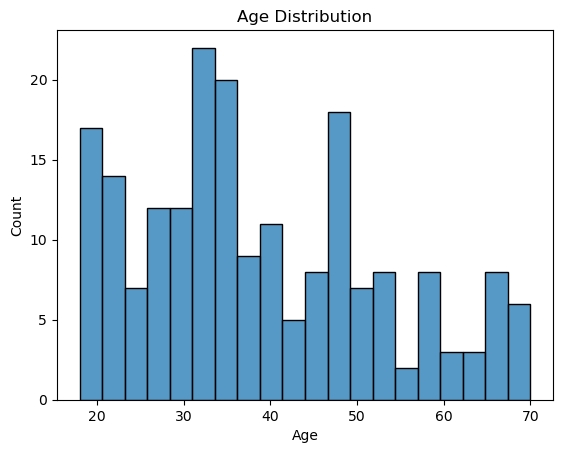

In [9]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

**Income Distribution**

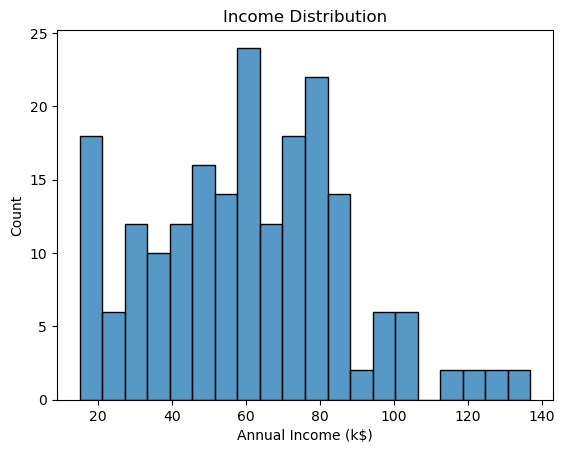

In [10]:
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Income Distribution")
plt.show()

**Spending Score Distribution**

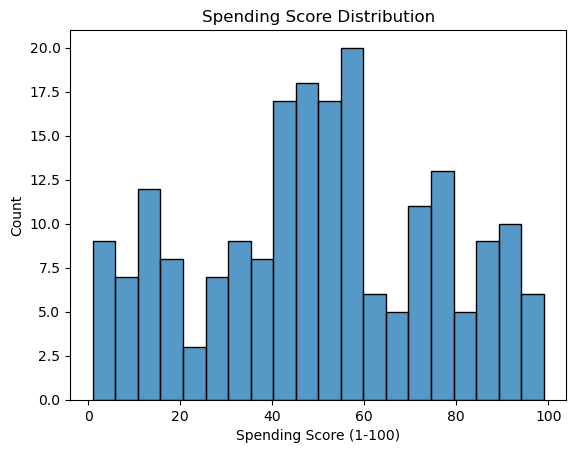

In [11]:
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

**Income vs Spending Behavior**

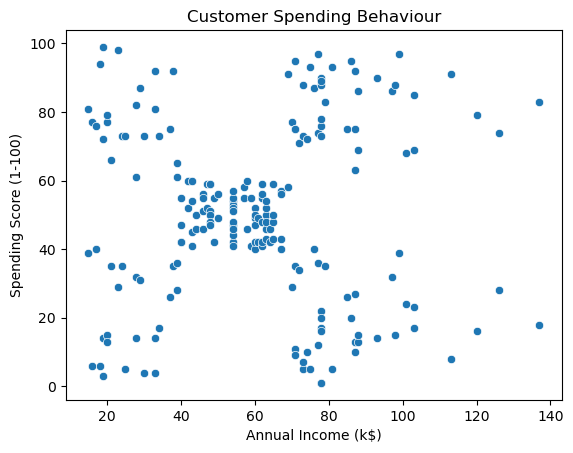

In [12]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Customer Spending Behaviour")
plt.show()

**7. Feature Selection**

Clustering will be performed using the following variables:

*Age*

*Annual Income*

*Spending Score*

In [13]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

**8. Feature Scaling**

**Why Scaling is Needed**

Clustering algorithms such as K-Means rely on distance calculations between observations. Because the variables in this dataset (Age, Annual Income, and Spending Score) are measured on different scales, feature standardization is applied to ensure that each variable contributes equally to the clustering process.

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**9. Finding Optimal Clusters (Elbow Method)**

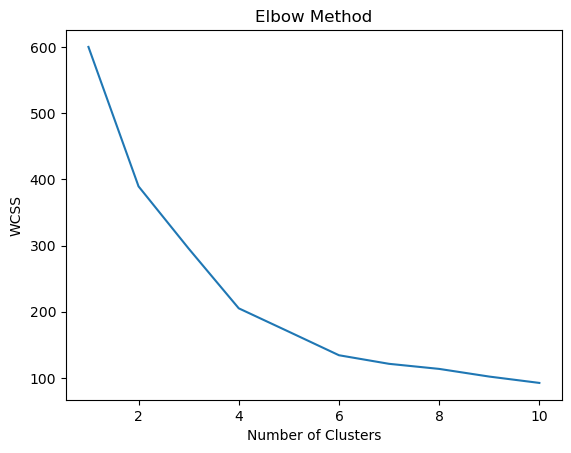

In [15]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The elbow method typically suggests 5 clusters.

**10. K-Means Clustering**

In [16]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

**Visualization**

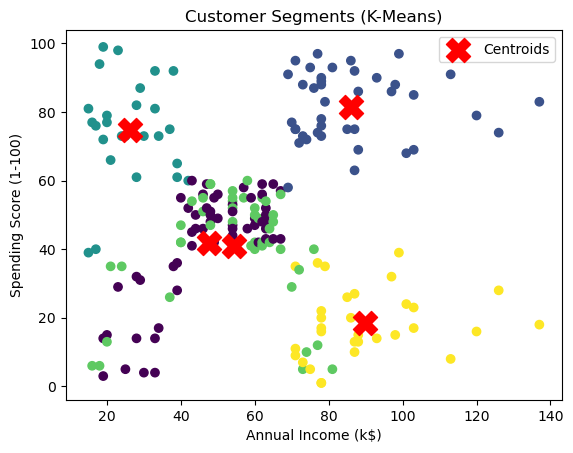

In [17]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters)

plt.scatter(
    centers[:,1],
    centers[:,2],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments (K-Means)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

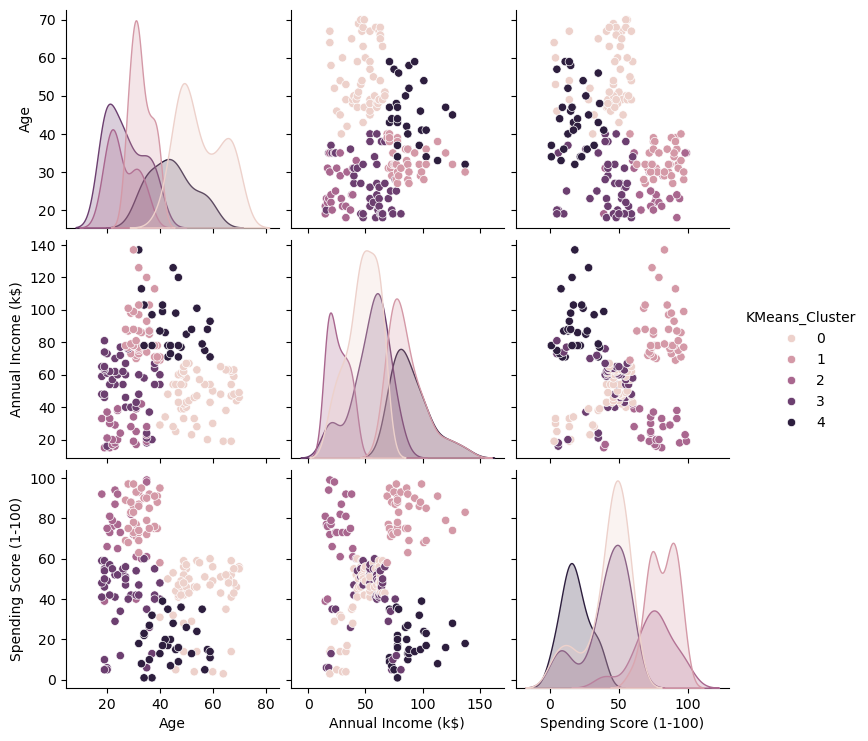

In [18]:
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)','KMeans_Cluster']], 
             hue='KMeans_Cluster')
plt.show()

**11. Gaussian Mixture Model**

Gaussian Mixture Models allow clusters to have different shapes and probabilities.

In [19]:
gmm = GaussianMixture(n_components=5, random_state=42)

gmm_clusters = gmm.fit_predict(X_scaled)

df['GMM_Cluster'] = gmm_clusters

**12. Hierarchical Clustering**

Hierarchical clustering groups customers by progressively merging clusters.

In [20]:
agg = AgglomerativeClustering(n_clusters=5)

agg_clusters = agg.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = agg_clusters

**13. Density-Based Clustering (DBSCAN)**

DBSCAN groups customers based on density of points.

In [21]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

**Comparing Clustering Algorithms**

In [22]:
kmeans_score = silhouette_score(X_scaled, clusters)
gmm_score = silhouette_score(X_scaled, gmm_clusters)
agg_score = silhouette_score(X_scaled, agg_clusters)

print("K-Means Silhouette Score:", round(kmeans_score,3))
print("GMM Silhouette Score:", round(gmm_score,3))
print("Hierarchical Silhouette Score:", round(agg_score,3))

K-Means Silhouette Score: 0.408
GMM Silhouette Score: 0.376
Hierarchical Silhouette Score: 0.39


Among the evaluated clustering methods, K-Means produced the most interpretable segmentation for this dataset. While other algorithms also identified meaningful groupings, K-Means provided clear and stable clusters suitable for marketing analysis.

**14. Model Evaluation**

Silhouette score measures cluster quality.

In [23]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.408


The silhouette score of 0.41 indicates moderate cluster separation. While some overlap exists between groups, the clusters are sufficiently distinct to provide meaningful customer segmentation for marketing analysis.

**15. Customer Segment Analysis**

Examining cluster characteristics

In [24]:
df.groupby('KMeans_Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


**Number of Customers per Segment**

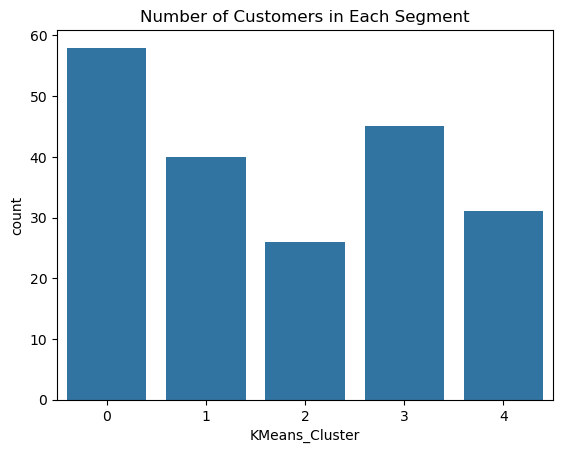

In [25]:
sns.countplot(x='KMeans_Cluster', data=df)
plt.title("Number of Customers in Each Segment")
plt.show()

**Interpretation of Each Cluster & Marketing Insights**

**Cluster 0**

- Age: 55
- Income: 48k
- Spending: 42

Interpretation:

- Older customers
- Moderate income
- Moderate spending

Marketing insight:

*These customers are steady but not high spenders.*

Possible strategies:

- Loyalty programs
- Product bundles
- Retention campaigns

**Cluster 1**

- Age: 33
- Income: 86k
- Spending: 82

Interpretation:

- Young
- High income
- High spending

This is your premium customer segment.

Marketing strategy:

- VIP membership
- Early product access
- Exclusive promotions

**Cluster 2**

- Age: 26
- Income: 26k
- Spending: 75

Interpretation:

- Young
- Low income
- High spending

*These customers like to spend despite lower income.*

Marketing strategy:

- Discounts
- Trend-driven products
- Social media campaigns

**Cluster 3**

- Age: 27
- Income: 54k
- Spending: 41

Interpretation:

- Young adults
- Moderate income
- Moderate spending

*This is the average customer segment.*

Marketing strategy:

- General marketing campaigns
- Product recommendations

**Cluster 4**

- Age: 44
- Income: 90k
- Spending: 18

Interpretation:

- Older
- High income
- Very low spending

This group has money but isn't spending much.

Marketing strategy:

- Upselling campaigns
- Personalized offers
- Product education

**17. Conclusions**

This project demonstrates how clustering algorithms can identify meaningful customer segments for targeted marketing.

The analysis applied several unsupervised learning techniques:

- K-Means Clustering
- Gaussian Mixture Models
- Hierarchical Clustering
- Density-Based Clustering (DBSCAN)

The results show that customer groups differ significantly in spending patterns and income levels. These insights can help marketing teams develop personalized campaigns that increase customer engagement and revenue.

**18. Project Tools**

- Python

- Pandas

- Scikit-learn

- Seaborn

- Matplotlib

- Jupyter Notebook